In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from math import erf, sqrt

In [3]:
X = np.array([
    [1, 2], [2, 2], [2, 3], [3, 3], [3, 4],
    [8, 8], [9, 8], [8, 9],
    [20, 20]   # Outlier
])

k = 2          # number of neighbors
lambda_val = 3 # scaling parameter (typically 2–3)

In [5]:
dist_matrix = cdist(X, X)

In [7]:
neighbors = []
for i in range(len(X)):
    sorted_idx = np.argsort(dist_matrix[i])
    neighbors.append(sorted_idx[1:k+1])  # exclude itself

neighbors = np.array(neighbors)

In [9]:
pdist = []
for i in range(len(X)):
    dists = dist_matrix[i][neighbors[i]]
    pd = np.sqrt(np.mean(dists**2))
    pdist.append(pd)

pdist = np.array(pdist)

In [11]:
plof = []
for i in range(len(X)):
    neighbor_pdist = np.mean([pdist[j] for j in neighbors[i]])
    if neighbor_pdist == 0:
        plof.append(0)
    else:
        plof.append((pdist[i] / neighbor_pdist) - 1)

plof = np.array(plof)

# Step 5: Compute normalization factor (nPLOF)
nplof = lambda_val * np.std(plof)

In [13]:
loop_scores = []
for val in plof:
    if nplof == 0:
        loop_scores.append(0)
    else:
        prob = max(0, erf(val / (nplof * sqrt(2))))
        loop_scores.append(prob)

loop_scores = np.array(loop_scores)

In [15]:
threshold = 0.5
outliers = loop_scores > threshold

# Print results
print("LoOP Scores:", loop_scores)
print("Outliers:\n", X[outliers])


LoOP Scores: [0.01550515 0.         0.         0.         0.01550515 0.
 0.00696975 0.00696975 0.71216094]
Outliers:
 [[20 20]]


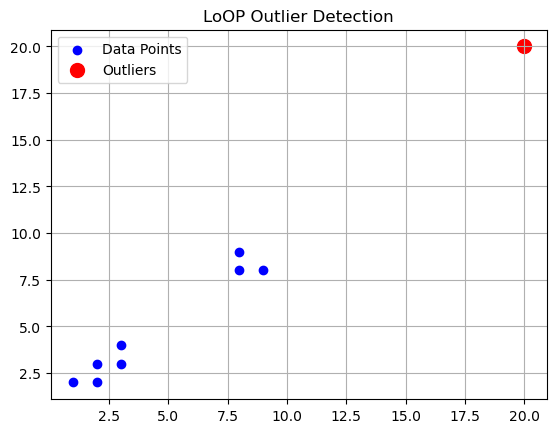

In [17]:
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Data Points')

if np.any(outliers):
    plt.scatter(X[outliers][:, 0], X[outliers][:, 1],
                color='red', s=100, label='Outliers')

plt.title("LoOP Outlier Detection")
plt.legend()
plt.grid()
plt.show()